In [1]:
from astroquery.vizier import Vizier
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from astropy.coordinates import SkyCoord, Angle
from astropy import units as u
from scipy.stats import norm
from scipy.optimize import curve_fit
import synthpop as sp
from mulens_rates import misc_utils
import pdb

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
v = Vizier(catalog="II/387/virac2")
v.ROW_LIMIT = -1

In [4]:
l=-10;b=-10
tcat = pd.read_hdf(f'outputfiles/virac/virac_l{l:.3f}_b{b:.3f}.h5')

In [5]:
tcat.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'Dist', 'l', 'b',
       'vr_bc', 'mul', 'mub', 'A_Ks', 'VISTA_Z', 'VISTA_Y', 'VISTA_J',
       'VISTA_H', 'VISTA_Ks'],
      dtype='object')

In [6]:
mod = sp.SynthPop(default_config='huston2025_defaults.synthpop_conf',
                          model_name="Huston2025", name_for_output='virac',
                          chosen_bands=["VISTA_Z", "VISTA_Y", "VISTA_J", "VISTA_H", "VISTA_Ks"],
                          maglim=['VISTA_Ks', 25, "remove"], output_location="outputfiles/virac",
                          skip_lowmass_stars=True, output_file_type='h5',
                          post_processing_kwargs={"name": "ProcessDarkCompactObjects","remove": False,
                                                  "name": "DropColumns", "column_names":['In_Final_Phase', 
                                                    'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR']},
                          opt_iso_props=[],
        )
mod.init_populations()

 3541 - Execution Date: 31-03-2026 16:42:15


################################ Settings #################################
 3542 - # reading default parameters from
 3542 - default_config_file =  /Users/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf 


# copy the following to a config file to redo this model generation -------
 3544 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "random_seed": 868874032,
    "name_for_output": "virac",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,
        "w_lsr": 0.53
    },
    "warp": {
        "r_warp": 7.72,
        "amp_warp": 0.06,
        "amp_warp_pos": null,
        "amp_warp

In [7]:
rad_deg = 0.05

In [8]:
def get_virac2(l,b):
    try:
        tab=pd.read_hdf(f'data/virac2/query_l{l:.3f}_b{b:.3f}.h5', key='data')
    except:
        print('Querying VIRAC2',l,b)
        coord = SkyCoord(l, b, unit=u.deg, frame='galactic')
        result = v.query_region(coord, radius=rad_deg*u.degree)[0]
        tab=result[result['UWE']<1.4]
        coords0 = SkyCoord(tab['RAJ2000'], tab['DEJ2000'],
                          pm_ra_cosdec=tab['pmRA'], pm_dec=tab['pmDE'], frame='icrs')
        coords = coords0.transform_to('galactic')
        tab['pml'] = coords.pm_l_cosb
        tab['pmb'] = coords.pm_b
        tab.to_pandas().to_hdf(f'data/virac2/query_l{l:.3f}_b{b:.3f}.h5', key='data')
        
    return tab

In [9]:
# def generate_spcat(l,b):
#     sptab = mod.process_location(l,b, solid_angle=np.pi*rad_deg**2)[0]

In [10]:
# rad_deg = np.sqrt(0.0011111111111111111/np.pi)

In [11]:
def get_spcat(l,b, blend=True):
    if blend:
        try:
            tab_bl=pd.read_hdf(f'outputfiles/virac/blend_full_l{l:.3f}_b{b:.3f}.h5')
            tab_bl['mul']
        except:
            try:
                sptab=pd.read_hdf(f'outputfiles/virac/virac_l{l:.3f}_b{b:.3f}.h5')
            except:
                sptab = mod.process_location(l,b, solid_angle=np.pi*rad_deg**2)[0]
            tab_bl = misc_utils.calc_blends(sptab, filters=['VISTA_J','VISTA_H','VISTA_Ks'], 
                                            blend_rad=0.36/3600, primary_filter='VISTA_Ks', calc_params=True)
            tab_bl.to_hdf(f'outputfiles/virac/blend_full_l{l:.3f}_b{b:.3f}.h5', 
                          index=False, key='data')
        return tab_bl
    try:
        sptab=pd.read_hdf(f'outputfiles/virac/virac_l{l:.3f}_b{b:.3f}.h5')
    except:
        sptab = mod.process_location(l,b, solid_angle=np.pi*rad_deg**2)[0]
    return sptab

In [12]:
# col = 'pml'; spcol='mul'
# tabbins = np.linspace(-30,30,51)
# hist = plt.hist(tab[col], bins=tabbins, histtype='step')
# sphist = np.histogram(sptab[spcol], bins=tabbins)[0]
# sphist = sphist*np.sum(hist[0])/np.sum(sphist)
# plt.stairs(sphist,tabbins)
# def Gauss(x, a, x0, sigma):
#     return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
# popt,pcov = curve_fit(Gauss, hist[1][:-1]+np.diff(hist[1])/2, hist[0], p0=[max(hist[0]), np.mean(tab[col]), np.std(tab[col])])
# print(popt)
# plt.plot(norm_bins, Gauss(norm_bins, *popt))
# spopt,spcov = curve_fit(Gauss, tabbins[:-1]+np.diff(tabbins)/2, sphist, p0=[max(sphist), np.mean(sptab[spcol]), np.std(sptab[spcol])])
# print(spopt)
# plt.plot(norm_bins, Gauss(norm_bins, *spopt))

In [13]:
# col = 'pmb'; spcol='mub'
# tabbins = np.linspace(-30,30,51)
# hist = plt.hist(tab[col], bins=tabbins, histtype='step')
# sphist = np.histogram(sptab[spcol], bins=tabbins)[0]
# sphist = sphist*np.sum(hist[0])/np.sum(sphist)
# plt.stairs(sphist,tabbins)
# def Gauss(x, a, x0, sigma):
#     return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
# popt,pcov = curve_fit(Gauss, hist[1][:-1]+np.diff(hist[1])/2, hist[0], p0=[max(hist[0]), np.mean(tab[col]), np.std(tab[col])])
# print(popt)
# plt.plot(norm_bins, Gauss(norm_bins, *popt))
# spopt,spcov = curve_fit(Gauss, tabbins[:-1]+np.diff(tabbins)/2, sphist, p0=[max(sphist), np.mean(sptab[spcol]), np.std(sptab[spcol])])
# print(spopt)
# plt.plot(norm_bins, Gauss(norm_bins, *spopt))
# #plt.yscale('log')
# #plt.ylim(1e0, 3e3)

In [14]:
# def make_cmd(l,b, clim=[0,1.5], ds=1, use_h=False, Kslim=17):
#     fig,ax=plt.subplots(nrows=1,ncols=4,figsize=(16,4))
#     tab=get_virac2(l,b)[::ds]
#     tab = tab[tab['Ksmag']<Kslim]
#     sptab=get_spcat(l,b)[::ds]
#     sptab = sptab[sptab['VISTA_Ks']<Kslim]
#     if not use_h:
#         ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, alpha=0.1, rasterized=True)
#         ax[1].plot(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], 'k.', markersize=2, alpha=0.1, rasterized=True)
#         ax[0].set_xlabel('J-Ks (mag.)')
#         ax[1].set_xlabel('J-Ks (mag.)')
#     else:
#         ax[0].plot(tab['Hmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, rasterized=True)
#         ax[1].plot(sptab['VISTA_H']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], 'k.', markersize=2, rasterized=True)
#         ax[0].set_xlabel('H-Ks (mag.)')
#         ax[1].set_xlabel('H-Ks (mag.)')
#     ax[0].set_title('VIRAC2',loc='left')
#     ax[1].set_title('SP-H25',loc='left')
#     for axi in ax[:2]:
#         axi.set_ylim(Kslim,11)
#         axi.set_xlim(*clim)
#     ax[0].set_ylabel('Ks (mag.)')
#     ax[0].text(clim[0]+0.05,11.3, 'VIRAC2\n'+str(len(tab[(tab['Ksmag']<Kslim) & (tab['Ksmag']>11)])))
#     ax[1].text(clim[0]+0.05,11.3, 'SP-H25\n'+str(len(sptab[(sptab['VISTA_Ks']<Kslim) & (sptab['VISTA_Ks']>11)])))
#     ax[0].grid(True)
#     ax[1].grid(True)
#     magbins = np.linspace(11,Kslim,13)
#     vlum = np.histogram(tab['Ksmag'], bins=magbins)[0]
#     splum = np.histogram(sptab['VISTA_Ks'], bins=magbins)[0]
#     ax[2].stairs(vlum/np.sum(vlum), magbins, label='VIRAC2')
#     ax[2].stairs(splum/np.sum(splum), magbins, label='SP-H25')
#     ax[2].legend()
#     ax[2].set_xlabel('Ks (mag.)')
#     ax[2].set_title('Luminosity Function', loc='left')
#     colbins = np.linspace(clim[0],clim[1],int(round((clim[1]-clim[0])/0.1))+1)
#     if not use_h:
#         vcol = np.histogram(tab['Jmag']-tab['Ksmag'], bins=colbins)[0]
#         spcol = np.histogram(sptab['VISTA_J']-sptab['VISTA_Ks'], bins=colbins)[0]
#         ax[3].set_xlabel('J-Ks (mag.)')
#     else:
#         vcol = np.histogram(tab['Hmag']-tab['Ksmag'], bins=colbins)[0]
#         spcol = np.histogram(sptab['VISTA_H']-sptab['VISTA_Ks'], bins=colbins)[0]
#         ax[3].set_xlabel('H-Ks (mag.)')
#     ax[3].stairs(vcol/np.sum(vcol), colbins)
#     ax[3].stairs(spcol/np.sum(spcol), colbins)
#     ax[3].set_title('Color Function', loc='left')
#     plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}.png')    
#     plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}.pdf', dpi=600)

In [16]:
def make_cmd_v2(l,b, clim=[0,1.5], ds=1, use_h=False, Kslim=17):
    plt.rcParams["font.size"] = 16
    fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(12,4.5))
    tab=get_virac2(l,b)[::ds]
    tab = tab[tab['Ksmag']<Kslim]
    sptab=get_spcat(l,b)[::ds]
    sptab = sptab[sptab['VISTA_Ks']<Kslim]
    if not use_h:
        ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, alpha=0.1, rasterized=True)
        ax[1].plot(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], '.', markersize=2, alpha=0.1, rasterized=True)
        ax[0].set_xlabel('J-Ks (mag.)')
        ax[1].set_xlabel('J-Ks (mag.)')
    else:
        ax[0].plot(tab['Hmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, rasterized=True)
        ax[1].scatter(sptab['VISTA_H']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], '.', markersize=2, rasterized=True)
        ax[0].set_xlabel('H-Ks (mag.)')
        ax[1].set_xlabel('H-Ks (mag.)')
    ax[0].set_title(f'({l:.1f},{b:.1f})',loc='left')
    #ax[1].set_title('SP-H25',loc='left')
    for axi in ax[:2]:
        axi.set_ylim(Kslim,11)
        axi.set_xlim(*clim)
    ax[0].set_ylabel('Ks (mag.)')
    ax[0].text(clim[0]+0.05,11.1, 'VIRAC2\n'+str(len(tab[(tab['Ksmag']<Kslim) & (tab['Ksmag']>11)])),
               ha='left',va='top')
    ax[1].text(clim[0]+0.05,11.1, 'SP-H25\n'+str(len(sptab[(sptab['VISTA_Ks']<Kslim) & (sptab['VISTA_Ks']>11)])),
               ha='left',va='top')
    ax[0].grid(True)
    ax[1].grid(True)
    magbins = np.linspace(11,Kslim,7*4+1)
    vlum = np.histogram(tab['Ksmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_Ks'], bins=magbins)[0]
    ax[2].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum),
                   label='VIRAC2', c='k', linestyle='none', marker='.')
    ax[2].stairs(splum, magbins, label='SP-H25')
    print(np.median(splum/vlum))
    print(splum/vlum)
    ax[2].legend()
    ax[2].set_xlabel('Ks (mag.)')
    #ax[2].set_title('Luminosity Function', loc='left')
    ax[2].set_yscale('log')
    ax[2].set_ylim(10,1e4)
    plt.tight_layout()
    plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_v2.png')    
    plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_v2.pdf', dpi=600)

1.410527508407278
[1.         1.2        1.52857143 1.67816092 1.52688172 1.18947368
 1.33928571 1.23026316 1.55813953 2.16820276 1.72820513 1.17381974
 1.27970297 1.13947991 1.19753086 1.11294118 1.33410138 1.40174672
 1.41877256 1.40228245 1.28164196 1.43806922 1.54453295 1.8053653
 2.36470037 3.26066536 4.11178862 5.98545455]


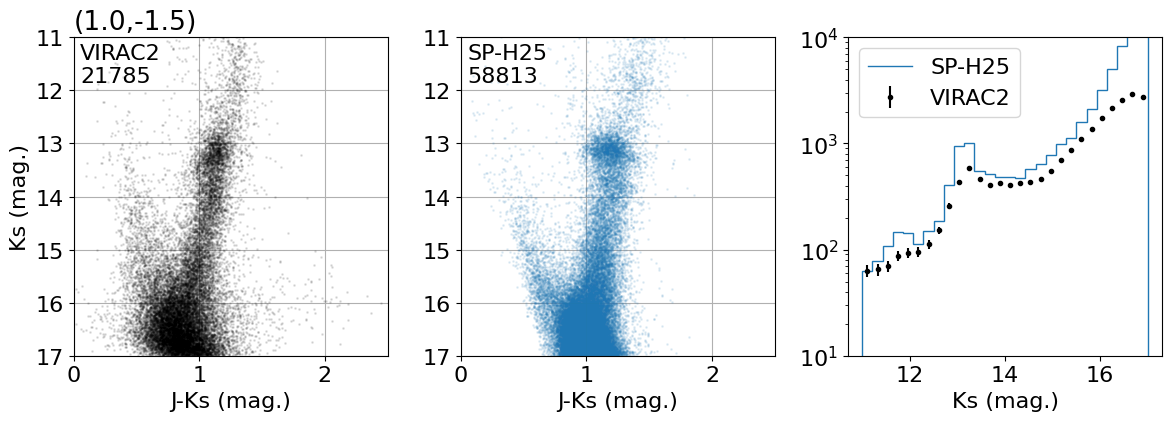

In [23]:
make_cmd_v2(1,-1.5,clim=[0,2.5])

1.061623831775701
[4.5        1.         1.0625     1.04166667 1.7826087  1.09375
 1.84615385 1.25641026 1.04918033 1.49473684 1.53125    1.45454545
 1.11304348 1.03478261 0.93859649 0.95412844 0.79020979 0.88414634
 1.01639344 1.06074766 1.04291845 1.10150376 1.08682635 0.91972477
 0.89465154 0.87850467 1.09140768 1.15876028]


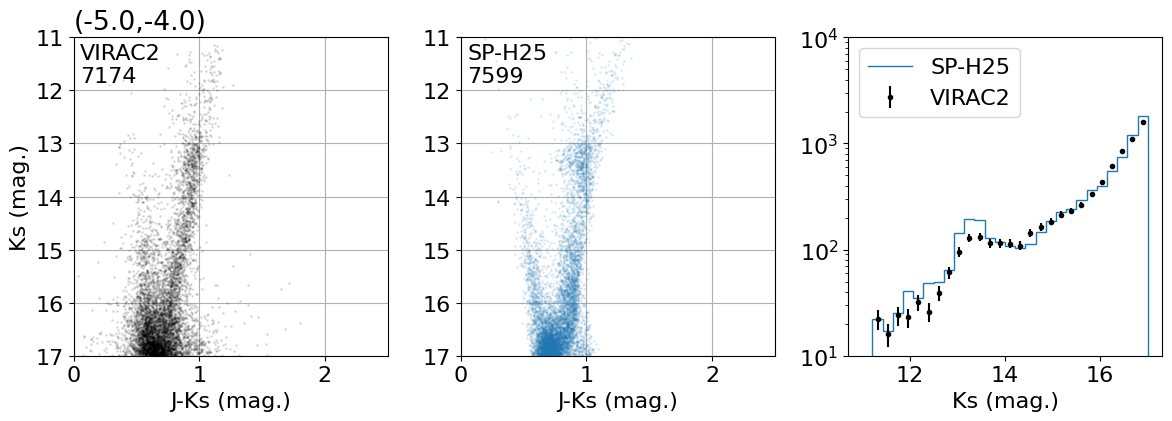

In [24]:
make_cmd_v2(-5,-4,clim=[0,2.5])

1.4293686868686868
[0.96296296 1.5        2.88235294 1.48484848 1.56097561 1.64705882
 1.12280702 1.11290323 1.71428571 2.17088608 2.03645833 1.35789474
 1.31055901 1.09803922 1.09493671 1.08       1.57246377 1.25252525
 1.46700508 1.44318182 1.36942675 1.21549637 1.32270916 1.2574103
 1.41555556 1.76403509 1.9309291  2.31194379]


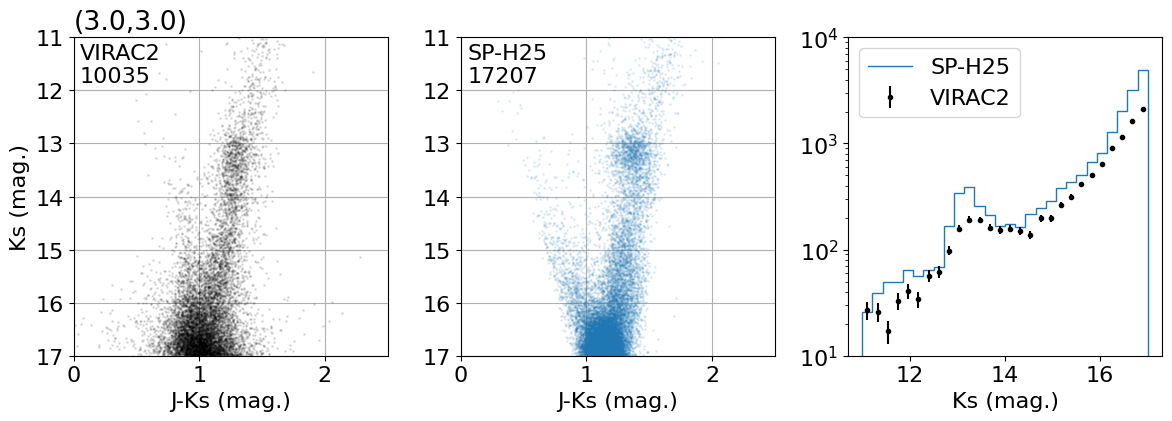

In [25]:
make_cmd_v2(3,3,clim=[0,2.5])

1.3775766729391568
[1.29333333 1.68115942 1.23809524 1.67777778 1.22077922 1.43137255
 1.2745098  1.25581395 1.72527473 1.55405405 2.0537428  1.92328042
 1.10206718 1.18309859 1.21922428 1.10989011 1.16920732 1.35439137
 1.28255208 1.39066059 1.35404896 1.36449275 1.65384615 2.11931188
 2.81906525 4.18259023 5.54012459 8.58705449]


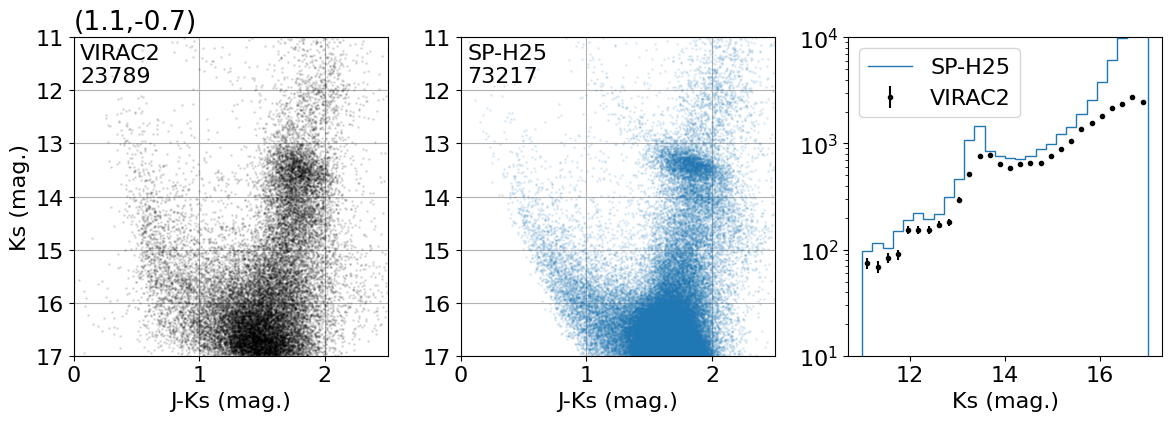

In [26]:
make_cmd_v2(1.1,-0.7,clim=[0,2.5])

In [30]:
coords = np.array([[ 1.25637826,  0.70123109,  5.41622252,  0.4467385 ],
       [-2.62450989, -1.49553414,  3.29532951, -7.12796143]]).T



############################# update location #############################
 917176 - # set location to: 
 917177 - l, b = (1.26 deg, -2.62 deg)
 917177 - # set solid_angle to:
 917177 - solid_angle = 1.111e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 919077 - bulge : estimate minimum mass for magnitude limit
 919112 - # From density profile (number density)
 919112 - expected_total_iMass = 239844.0476
 919112 - expected_total_eMass = 130612.3313
 919113 - average_iMass_per_star = 0.5739
 919113 - mass_loss_correction = 0.5446
 919113 - n_expected_stars = 417944.3758
 919113 - without_lm_stars = 417944.3758
 919114 - # Determine velocities when position are generated 


  0%|          | 0/417223 [00:00<?, ?it/s]

 922927 - # From Generated Field:
 922927 - generated_stars = 330308
 922928 - generated_total_iMass = 105598.4301
 922953 - generated_total_iMass_incl_lowmass = 105598.4301
 922954 - generated_total_eMass = 105570.7969
 922959 - generated_total_eMass_incl_lowmass = 105570.7969
 922960 - det_mass_loss_corr = 0.9997
 922960 - det_mass_loss_corr_incl_lowmass = 0.9997383180102521
 922965 - # Done


# Population 1;  halo -----------------------------------------------------
 923284 - halo : estimate minimum mass for magnitude limit
 923318 - # From density profile (number density)
 923319 - expected_total_iMass = 430.6730
 923319 - expected_total_eMass = 227.1473
 923319 - average_iMass_per_star = 0.5739
 923319 - mass_loss_correction = 0.5274
 923320 - n_expected_stars = 750.4766
 923320 - without_lm_stars = 749.0616
 923320 - # Determine velocities when position are generated 
 923363 - # From Generated Field:
 923363 - generated_stars = 561
 923363 - generated_total_iMass = 161.2439
 92

1.2097663854639844
[1.16666667 0.57142857 1.375      1.1        0.69230769 0.3
 0.83333333 1.5625     1.61764706 2.35555556 1.51219512 1.13157895
 0.66666667 0.82051282 1.55555556 1.1875     1.48648649 1.19565217
 1.18181818 1.2238806  1.30379747 1.02040816 1.01428571 1.30909091
 1.95588235 2.26482213 2.59428571 2.8364486 ]


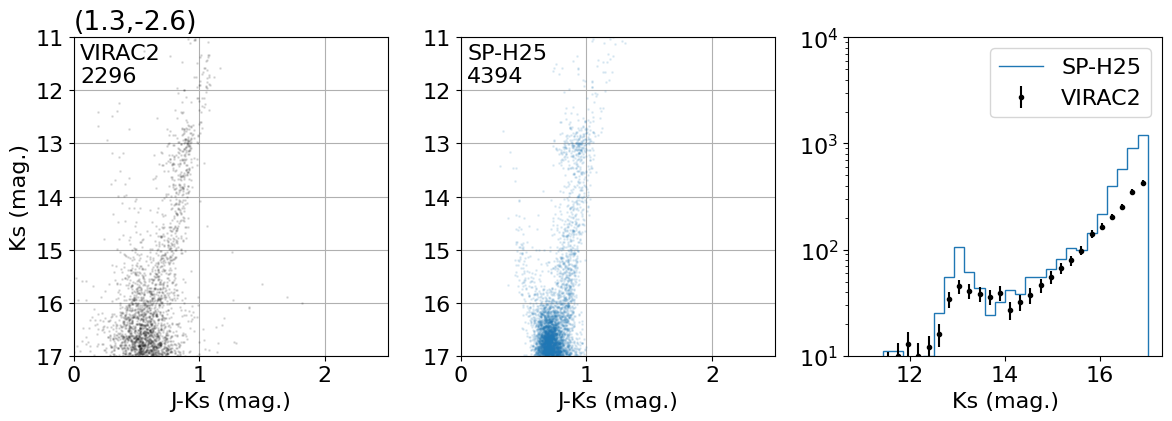

In [40]:
make_cmd_v2(*coords[0],clim=[0,2.5])



############################# update location #############################
 930204 - # set location to: 
 930204 - l, b = (0.70 deg, -1.50 deg)
 930205 - # set solid_angle to:
 930206 - solid_angle = 1.111e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 931952 - bulge : estimate minimum mass for magnitude limit
 931987 - # From density profile (number density)
 931988 - expected_total_iMass = 413810.0874
 931988 - expected_total_eMass = 225349.3501
 931988 - average_iMass_per_star = 0.5739
 931988 - mass_loss_correction = 0.5446
 931989 - n_expected_stars = 721091.8946
 931989 - without_lm_stars = 721091.8946
 931989 - # Determine velocities when position are generated 


  0%|          | 0/719153 [00:00<?, ?it/s]

 938704 - # From Generated Field:
 938704 - generated_stars = 568778
 938705 - generated_total_iMass = 182045.5542
 938746 - generated_total_iMass_incl_lowmass = 182045.5542
 938747 - generated_total_eMass = 182006.0879
 938756 - generated_total_eMass_incl_lowmass = 182006.0879
 938756 - det_mass_loss_corr = 0.9998
 938756 - det_mass_loss_corr_incl_lowmass = 0.9997832065300767
 938764 - # Done


# Population 1;  halo -----------------------------------------------------
 939095 - halo : estimate minimum mass for magnitude limit
 939129 - # From density profile (number density)
 939129 - expected_total_iMass = 582.8035
 939129 - expected_total_eMass = 307.3846
 939129 - average_iMass_per_star = 0.5739
 939130 - mass_loss_correction = 0.5274
 939130 - n_expected_stars = 1015.5743
 939130 - without_lm_stars = 1014.1486
 939130 - # Determine velocities when position are generated 
 939174 - # From Generated Field:
 939175 - generated_stars = 735
 939175 - generated_total_iMass = 210.3773
 

1.3568768619662364
[1.57142857 1.3        1.33333333 1.44444444 1.66666667 0.72727273
 1.5625     1.35294118 1.08823529 1.68181818 2.14457831 1.
 1.07246377 0.95384615 1.35849057 1.23214286 1.125      1.22666667
 1.35526316 1.51111111 1.23255814 1.32727273 1.63402062 1.93562232
 2.41077441 3.13611111 3.86966292 5.48067633]


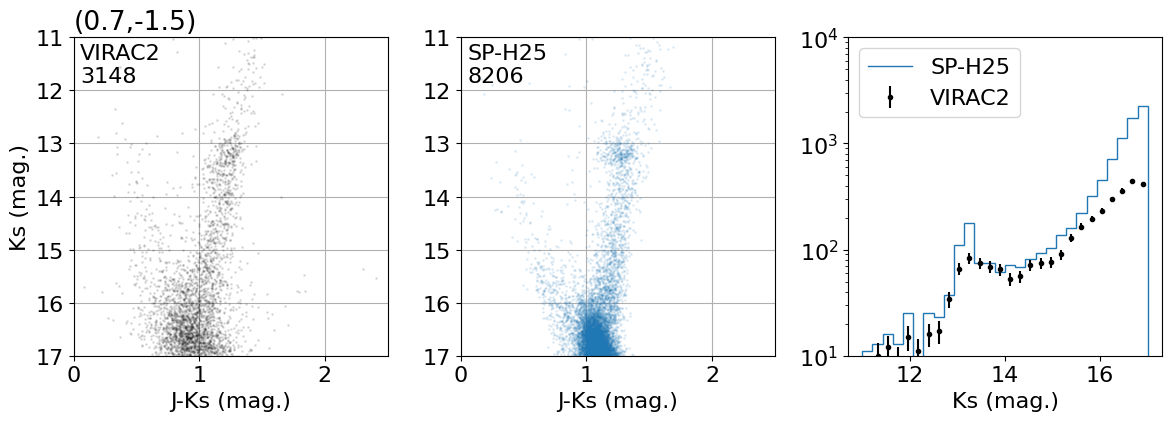

In [41]:
make_cmd_v2(*coords[1],clim=[0,2.5])



############################# update location #############################
 948309 - # set location to: 
 948309 - l, b = (5.42 deg, 3.30 deg)
 948309 - # set solid_angle to:
 948310 - solid_angle = 1.111e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 950113 - bulge : estimate minimum mass for magnitude limit
 950148 - # From density profile (number density)
 950148 - expected_total_iMass = 92769.6614
 950148 - expected_total_eMass = 50519.7518
 950149 - average_iMass_per_star = 0.5739
 950149 - mass_loss_correction = 0.5446
 950149 - n_expected_stars = 161657.3712
 950149 - without_lm_stars = 161657.3712
 950150 - # Determine velocities when position are generated 
 951649 - # From Generated Field:
 951649 - generated_stars = 127651
 951650 - generated_total_iMass = 40704.6889
 951664 - generated_total_iMass_incl_lowmass = 40704.6889
 951664 - generated_total_eMas

1.1335268505079825
[0.33333333 1.33333333 1.66666667        inf 1.66666667 1.
 3.5        0.84615385 1.53333333 2.4        1.72222222 1.
 0.93333333 0.5        0.9375     1.15384615 1.25       0.85185185
 1.04761905 1.45454545 1.08888889 0.93220339 1.11320755 0.8974359
 0.92063492 1.3        1.39593909 1.32330827]


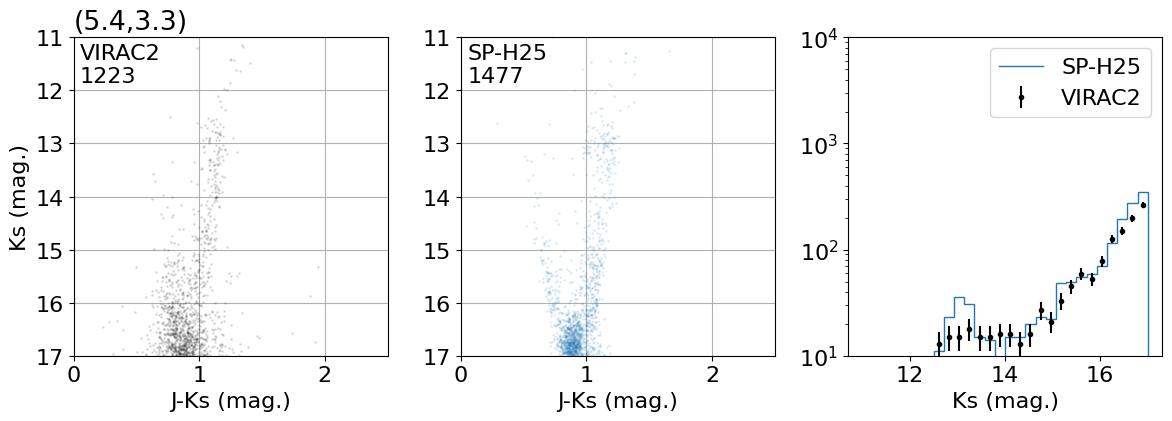

In [42]:
make_cmd_v2(*coords[2],clim=[0,2.5])



############################# update location #############################
 958086 - # set location to: 
 958086 - l, b = (0.45 deg, -7.13 deg)
 958087 - # set solid_angle to:
 958087 - solid_angle = 1.111e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 959918 - bulge : estimate minimum mass for magnitude limit
 959953 - # From density profile (number density)
 959953 - expected_total_iMass = 27526.3445
 959953 - expected_total_eMass = 14990.0740
 959954 - average_iMass_per_star = 0.5739
 959954 - mass_loss_correction = 0.5446
 959954 - n_expected_stars = 47966.5056
 959954 - without_lm_stars = 47966.5056
 959954 - # Determine velocities when position are generated 
 960434 - # From Generated Field:
 960434 - generated_stars = 38080
 960434 - generated_total_iMass = 12135.0618
 960441 - generated_total_iMass_incl_lowmass = 12135.0618
 960442 - generated_total_eMass 

1.1619850187265919
[       inf 0.33333333 0.5               inf 1.5        1.
 0.         4.5        4.         2.         0.5        2.33333333
 1.2        0.66666667 1.         1.33333333 0.71428571 1.125
 0.90909091 1.5        1.16666667 0.7        1.36842105 0.92857143
 1.5483871  0.84745763 1.46428571 1.15730337]


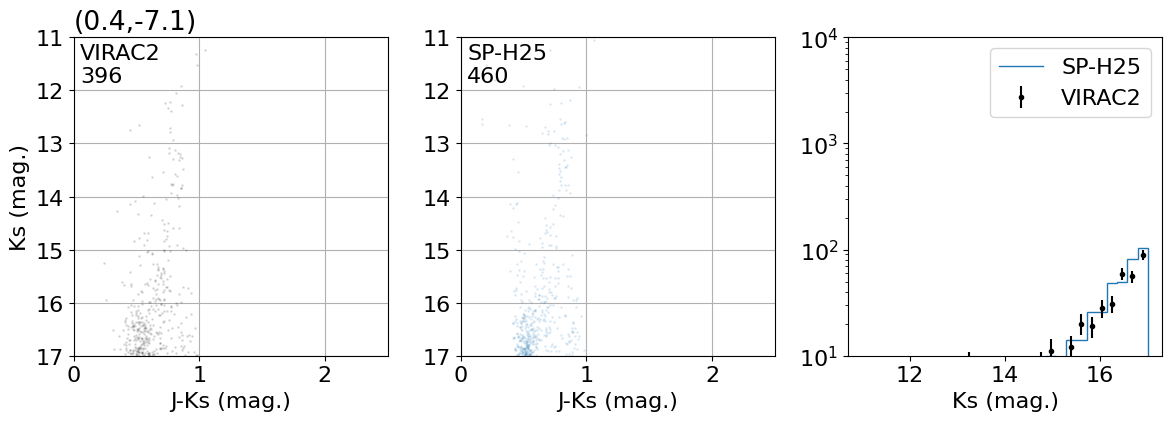

In [43]:
make_cmd_v2(*coords[3],clim=[0,2.5])

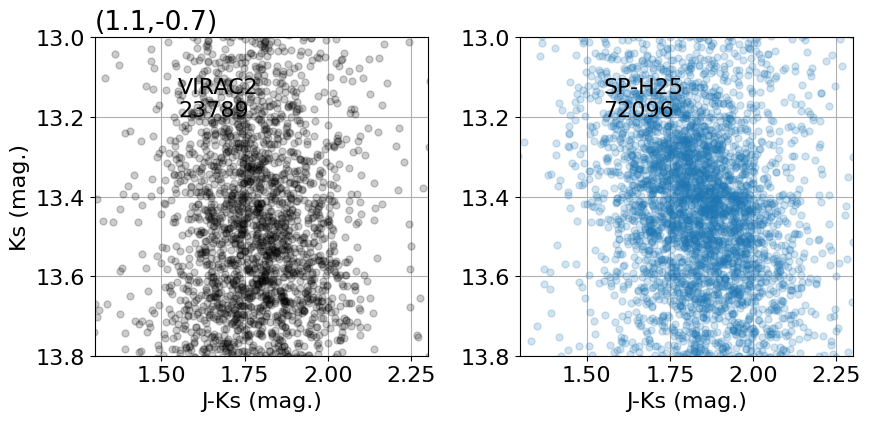

In [32]:
l,b = 1.1,-0.7; clim=[0,2.5]; Kslim=17
plt.rcParams["font.size"] = 16
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(9,4.5))
tab=get_virac2(l,b)
tab = tab[tab['Ksmag']<Kslim]
sptab=get_spcat(l,b)
sptab = sptab[sptab['VISTA_Ks']<Kslim]
ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=10, alpha=0.2, rasterized=True)
ax[1].plot(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], '.', markersize=10, alpha=0.2, rasterized=True)
ax[0].set_xlabel('J-Ks (mag.)')
ax[1].set_xlabel('J-Ks (mag.)')
ax[0].set_title(f'({l:.1f},{b:.1f})',loc='left')
#ax[1].set_title('SP-H25',loc='left')
for axi in ax:
    axi.set_ylim(13.8,13)
    axi.set_xlim(1.3,2.3)
ax[0].set_ylabel('Ks (mag.)')
ax[0].text(1.5+0.05,13.1, 'VIRAC2\n'+str(len(tab[(tab['Ksmag']<Kslim) & (tab['Ksmag']>11)])),
           ha='left',va='top')
ax[1].text(1.5+0.05,13.1, 'SP-H25\n'+str(len(sptab[(sptab['VISTA_Ks']<Kslim) & (sptab['VISTA_Ks']>11)])),
           ha='left',va='top')
ax[0].grid(True)
ax[1].grid(True)
plt.tight_layout()
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.png')    
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.pdf', dpi=600)



############################# update location #############################
 74458685 - # set location to: 
 74458686 - l, b = (0.40 deg, -1.40 deg)
 74458686 - # set solid_angle to:
 74458686 - solid_angle = 7.854e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 74460494 - bulge : estimate minimum mass for magnitude limit
 74460529 - # From density profile (number density)
 74460529 - expected_total_iMass = 3120934.7931
 74460529 - expected_total_eMass = 1702291.8365
 74460530 - average_iMass_per_star = 0.5739
 74460530 - mass_loss_correction = 0.5454
 74460530 - n_expected_stars = 5438438.6740
 74460531 - without_lm_stars = 5438438.6740
 74460531 - # Determine velocities when position are generated 


  0%|          | 0/5438642 [00:00<?, ?it/s]

 74517121 - # From Generated Field:
 74517122 - generated_stars = 4304346
 74517123 - generated_total_iMass = 1377844.0748
 74517462 - generated_total_iMass_incl_lowmass = 1377844.0748
 74517463 - generated_total_eMass = 1377562.0310
 74517534 - generated_total_eMass_incl_lowmass = 1377562.0310
 74517535 - det_mass_loss_corr = 0.9998
 74517535 - det_mass_loss_corr_incl_lowmass = 0.9997953006273631
 74517577 - # Done


# Population 1;  halo -----------------------------------------------------
 74517912 - halo : estimate minimum mass for magnitude limit
 74517948 - # From density profile (number density)
 74517948 - expected_total_iMass = 4204.9284
 74517949 - expected_total_eMass = 2210.0970
 74517949 - average_iMass_per_star = 0.5739
 74517949 - mass_loss_correction = 0.5256
 74517949 - n_expected_stars = 7327.3705
 74517950 - without_lm_stars = 7317.2513
 74517950 - # Determine velocities when position are generated 
 74518063 - # From Generated Field:
 74518063 - generated_stars = 5

  0%|          | 0/322653 [00:00<?, ?it/s]

 74545731 - # From Generated Field:
 74545732 - generated_stars = 241284
 74545732 - generated_total_iMass = 79176.7604
 74545753 - generated_total_iMass_incl_lowmass = 79288.0132
 74545753 - generated_total_eMass = 79158.7078
 74545757 - generated_total_eMass_incl_lowmass = 79269.9606
 74545758 - det_mass_loss_corr = 0.9998
 74545758 - det_mass_loss_corr_incl_lowmass = 0.9997723161714027
 74545761 - # Done


########################### Combine Populations ###########################
 74545902 - Number of stars generated: 4848773 (25 columns)
 74545902 - remove stars which are outside of the isochrone grid 
 74546601 - cleand field: Number of stars generated: 4848773 (25 columns)
 74546602 - included_columns = ['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'VISTA_Z', 'VISTA_Y', 'VISTA_J', 'VISTA_H', 'VISTA_Ks']


# Save result -----------------------------------------------------

  0%|          | 0/4848773 [00:00<?, ?it/s]

1.3923633305298568
[1.25862069 1.59615385 1.3902439  1.61290323 1.39       1.19811321
 1.22413793 1.35616438 1.46082949 2.00273973 2.         1.28
 1.17827869 1.24711316 0.99576271 1.16861827 1.34858388 1.24117647
 1.34747145 1.39448276 1.44808126 1.55385996 1.88235294 2.219036
 2.81620553 3.76585977 4.77860604 9.06855919]


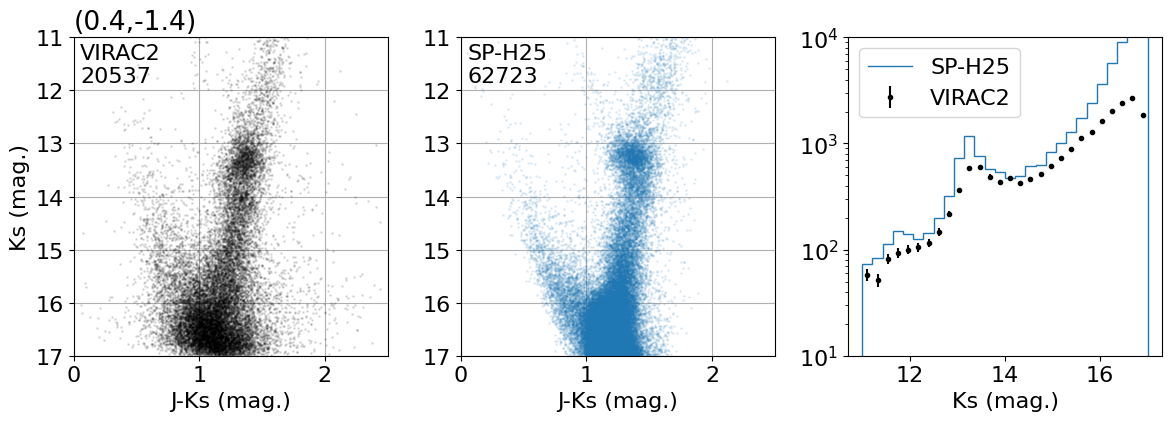

In [33]:
make_cmd_v2(0.4,-1.4,clim=[0,2.5])

KeyError: 'phase'

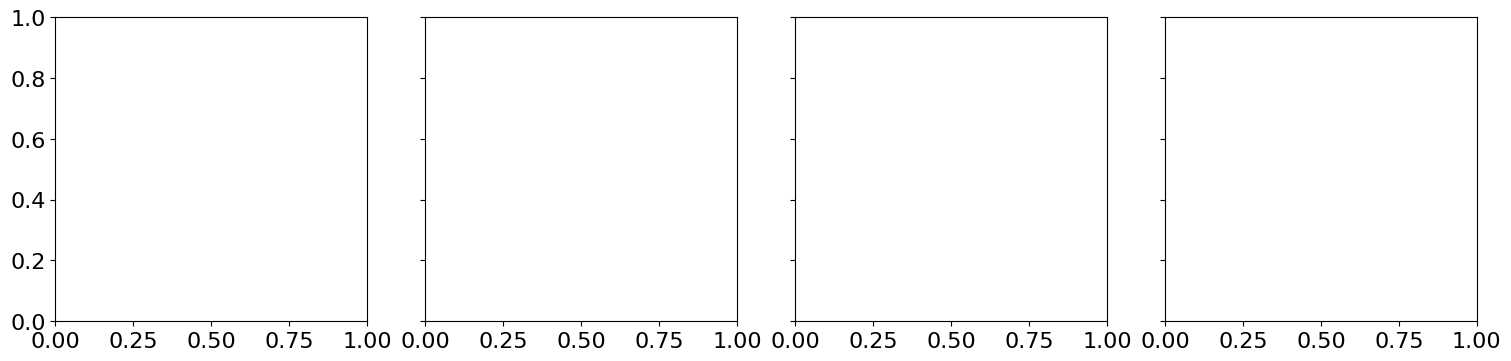

In [34]:
l,b = 0.4,-1.4; clim=[0,2.5]; Kslim=17
plt.rcParams["font.size"] = 16
fig,ax=plt.subplots(nrows=1,ncols=4,figsize=(15,3.5),sharey=True, layout='constrained')
tab=get_virac2(l,b)
tab = tab[tab['Ksmag']<Kslim]
sptab0=get_spcat(l,b,blend=False)
sptab = sptab0[(sptab0['VISTA_Ks']<Kslim) & (np.abs(sptab0['phase']-3)<0.5) & (sptab0['pop']==0.0)]
sptab2 = sptab0[(sptab0['VISTA_Ks']<Kslim) & ((np.abs(sptab0['phase']-3)>0.5) | (sptab0['pop']!=0.0))]
ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=5, alpha=0.2, rasterized=True)
c1 = ax[1].scatter(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], marker='.', 
              s=50, alpha=0.3, rasterized=True, c=sptab['Fe/H_initial'],cmap='viridis',vmin=-1.3,vmax=0.5)
ax[1].scatter(sptab2['VISTA_J']-sptab2['VISTA_Ks'], sptab2['VISTA_Ks'], marker='.', 
              s=50, alpha=0.1, rasterized=True, c='k',zorder=-100)
ax[2].scatter(sptab2['VISTA_J']-sptab2['VISTA_Ks'], sptab2['VISTA_Ks'], marker='.', 
              s=50, alpha=0.1, rasterized=True, c='k',zorder=-100)
ax[3].scatter(sptab2['VISTA_J']-sptab2['VISTA_Ks'], sptab2['VISTA_Ks'], marker='.', 
              s=50, alpha=0.1, rasterized=True, c='k',zorder=-100)
c2 = ax[2].scatter(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], marker='.', 
              s=50, alpha=0.3, rasterized=True, c=sptab['A_Ks'],cmap='viridis',vmin=0.2,vmax=0.35)
c3 = ax[3].scatter(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], marker='.', 
              s=50, alpha=0.3, rasterized=True, c=sptab['Dist'],cmap='viridis',vmin=6.1,vmax=10.7)
plt.colorbar(c1, label='[Fe/H]')
plt.colorbar(c2, label='A_Ks')
plt.colorbar(c3, label='Distance (kpc)')
sel = sptab[(sptab['VISTA_Ks']<13.8) & (sptab['VISTA_Ks']>12.6) & 
            (sptab['VISTA_J']-sptab['VISTA_Ks']>1) & 
            (sptab['VISTA_J']-sptab['VISTA_Ks']<1.8)]
print(np.min(sel['Fe/H_initial']), np.max(sel['Fe/H_initial']))
print(np.min(sel['A_Ks']), np.max(sel['A_Ks']))
print(np.min(sel['Dist']), np.max(sel['Dist']))
ax[0].set_title(f'VIRAC2 ({l:.1f},{b:.1f})',loc='left')
ax[1].set_title('SP-H25',loc='left')
for axi in ax:
    axi.set_ylim(13.8,12.6)
    axi.set_xlim(1.0,1.8)
    axi.set_xlabel('J-Ks (mag.)')
    axi.grid(True)
ax[0].set_ylabel('Ks (mag.)')
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.png')    
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.pdf', dpi=600)

In [ ]:
make_cmd_v2(0.05,-0.2,clim=[0,10])

In [ ]:
def make_lf(l,b, clim=[0,1.5], ds=1,Kslim=18):
    fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(12,4))
    tab=get_virac2(l,b)[::ds]
    #tab = tab[tab['Ksmag']<Kslim]
    sptab=get_spcat(l,b)[::ds]
    #sptab = sptab[sptab['VISTA_Ks']<Kslim]

    magbins = np.linspace(11,Kslim,13)
    vlum = np.histogram(tab['Jmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_J'], bins=magbins)[0]
    ax[0].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum), label='VIRAC2',
                  linestyle='none', marker='.', c='k')
    ax[0].stairs(splum, magbins, label='SP-H25')
    ax[0].legend()
    ax[0].set_xlabel('J (mag.)')
    ax[0].set_title('Luminosity Function', loc='left')
    ax[0].set_yscale('log')

    magbins = np.linspace(11,Kslim,13)
    vlum = np.histogram(tab['Hmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_H'], bins=magbins)[0]
    ax[1].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum), label='VIRAC2',
                  linestyle='none', marker='.', c='k')
    ax[1].stairs(splum, magbins, label='SP-H25')
    ax[1].legend()
    ax[1].set_xlabel('H (mag.)')
    ax[1].set_title('Luminosity Function', loc='left')
    ax[1].set_yscale('log')

    magbins = np.linspace(11,Kslim,13)
    vlum = np.histogram(tab['Ksmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_Ks'], bins=magbins)[0]
    ax[2].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum), label='VIRAC2',
                  linestyle='none', marker='.', c='k')
    ax[2].stairs(splum, magbins, label='SP-H25')
    ax[2].legend()
    ax[2].set_xlabel('Ks (mag.)')
    ax[2].set_title('Luminosity Function', loc='left')
    ax[2].set_yscale('log')

    plt.savefig(f'figures/virac2_lf_l{l:0.3f}_b{b:0.3f}.png')    
    plt.savefig(f'figures/virac2_lf_l{l:0.3f}_b{b:0.3f}.pdf', dpi=600)

In [ ]:
make_lf(-5,-4)

In [ ]:
make_lf(0,0)

In [ ]:
make_lf(0,-0.5)

In [92]:
# for l in range(-10,11):
#     for b in range(-10,6):
#         get_virac2(l,b)

Querying VIRAC2 10 5


In [54]:
# for l in range(1,11):
#     for b in range(-10,6):
#         generate_spcat(l,b)



############################# update location #############################
 137895661 - # set location to: 
 137895662 - l, b = (1.00 deg, -10.00 deg)
 137895662 - # set solid_angle to:
 137895663 - solid_angle = 7.854e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 137897602 - bulge : estimate minimum mass for magnitude limit
 137897640 - # From density profile (number density)
 137897641 - expected_total_iMass = 47918.7610
 137897641 - expected_total_eMass = 26136.9497
 137897641 - average_iMass_per_star = 0.5739
 137897642 - mass_loss_correction = 0.5454
 137897642 - n_expected_stars = 83501.6622
 137897642 - without_lm_stars = 83501.6622
 137897643 - # Determine velocities when position are generated 


KeyboardInterrupt: 

In [56]:
for l in [-6]:
    for b in range(0,6):
        print(l,b)
        get_spcat(l,b)

-6 0


  0%|          | 0/2180647 [00:00<?, ?it/s]

-6 1


  0%|          | 0/1828308 [00:00<?, ?it/s]

-6 2


  0%|          | 0/1313510 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [17]:
for l in range(-5,11):
    for b in range(-10,6):
        print(l,b)
        get_spcat(l,b)

-5 -10
-5 -9
-5 -8
-5 -7
-5 -6
-5 -5
-5 -4
-5 -3
-5 -2
-5 -1
-5 0
-5 1
-5 2
-5 3
-5 4
-5 5
-4 -10
-4 -9
-4 -8
-4 -7
-4 -6
-4 -5
-4 -4
-4 -3
-4 -2
-4 -1
-4 0
-4 1
-4 2
-4 3
-4 4
-4 5
-3 -10
-3 -9
-3 -8
-3 -7
-3 -6
-3 -5
-3 -4
-3 -3
-3 -2
-3 -1
-3 0
-3 1
-3 2
-3 3
-3 4
-3 5
-2 -10
-2 -9
-2 -8
-2 -7
-2 -6
-2 -5
-2 -4
-2 -3
-2 -2
-2 -1
-2 0
-2 1
-2 2
-2 3
-2 4
-2 5
-1 -10
-1 -9
-1 -8
-1 -7
-1 -6
-1 -5
-1 -4
-1 -3
-1 -2
-1 -1
-1 0
-1 1
-1 2
-1 3
-1 4
-1 5
0 -10
0 -9
0 -8
0 -7
0 -6
0 -5
0 -4
0 -3
0 -2
0 -1
0 0
0 1
0 2
0 3
0 4
0 5
1 -10
1 -9
1 -8
1 -7
1 -6
1 -5
1 -4
1 -3
1 -2
1 -1
1 0
1 1
1 2
1 3
1 4
1 5
2 -10
2 -9
2 -8
2 -7
2 -6
2 -5
2 -4
2 -3
2 -2
2 -1
2 0
2 1
2 2
2 3
2 4
2 5
3 -10
3 -9
3 -8
3 -7
3 -6
3 -5
3 -4
3 -3
3 -2
3 -1
3 0
3 1
3 2
3 3
3 4
3 5
4 -10
4 -9
4 -8
4 -7
4 -6
4 -5
4 -4
4 -3
4 -2
4 -1
4 0
4 1
4 2
4 3
4 4
4 5
5 -10
5 -9
5 -8
5 -7
5 -6
5 -5
5 -4
5 -3
5 -2
5 -1
5 0
5 1
5 2
5 3
5 4
5 5
6 -10
6 -9
6 -8
6 -7
6 -6
6 -5
6 -4
6 -3
6 -2
6 -1
6 0
6 1
6 2
6 3
6 4
6 5
7 -10
7 -9
7 -8
7 -7

In [28]:
ls,bs,vmul,smul,vmub,smub = [],[],[],[],[],[]
coords = []
for l in range(-10,11):
    print('l',l)
    for b in range(-10,6):
        vcat = get_virac2(l,b)
        vcat = vcat[vcat['MedKsmag']<16]
        scat = get_spcat(l,b,blend=True)
        scat = scat[scat['VISTA_Ks']<16]
        ls.append(l); bs.append(b)
        vmul.append(np.median(vcat['pml']))
        vmub.append(np.median(vcat['pmb']))
        smul.append(np.median(scat['mul']))
        smub.append(np.median(scat['mub']))

l -10
l -9
l -8
l -7
l -6
l -5
l -4
l -3
l -2
l -1
l 0
l 1
l 2
l 3
l 4
l 5
l 6
l 7
l 8
l 9
l 10


In [29]:
which = np.array(smul)>-4
np.array(ls)[which], np.array(bs)[which]

(array([], dtype=int64), array([], dtype=int64))

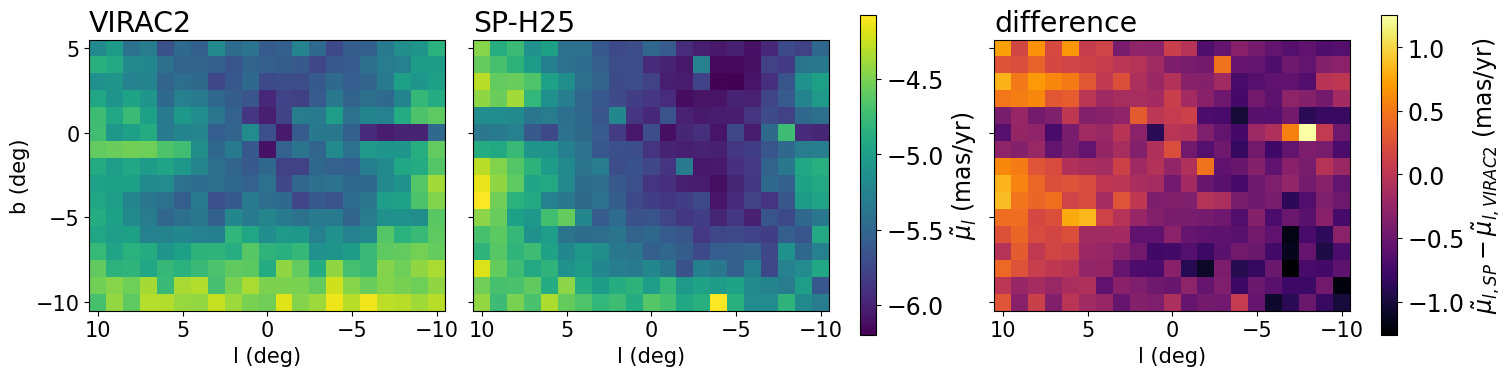

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharey=True)
plt.rcParams["font.size"] = 17

vmin = np.min(vmul+smul)
vmax = np.max(vmul+smul)

vmuls = np.reshape(vmul,(21,16)).T
virac = axes[0].imshow(vmuls, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("VIRAC2", loc='left')
axes[0].set_xlabel("l (deg)")
axes[0].set_ylabel("b (deg)")
axes[0].invert_xaxis()

smuls = np.reshape(smul,(21,16)).T
synthpop = axes[1].imshow(smuls, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("SP-H25", loc='left')
axes[1].set_xlabel("l (deg)")
axes[1].invert_xaxis()
fig.colorbar(synthpop, ax=axes[1], orientation="vertical", label=r"$\tilde{\mu}_l$ (mas/yr)", shrink=0.65)


diff = axes[2].imshow(smuls-vmuls, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="inferno")#, vmin=vmin, vmax=vmax)
axes[2].set_title("difference", loc='left')
axes[2].set_xlabel("l (deg)")
#axes[2].set_ylabel("b (deg)")
axes[2].invert_xaxis()

fig.colorbar(diff, ax=axes[2], orientation="vertical", 
             label=r"$\tilde{\mu}_{l,SP}-\tilde{\mu}_{l,VIRAC2}$ (mas/yr)", shrink=0.65)

plt.savefig("figures/virac_mul_maps.pdf")
plt.show()

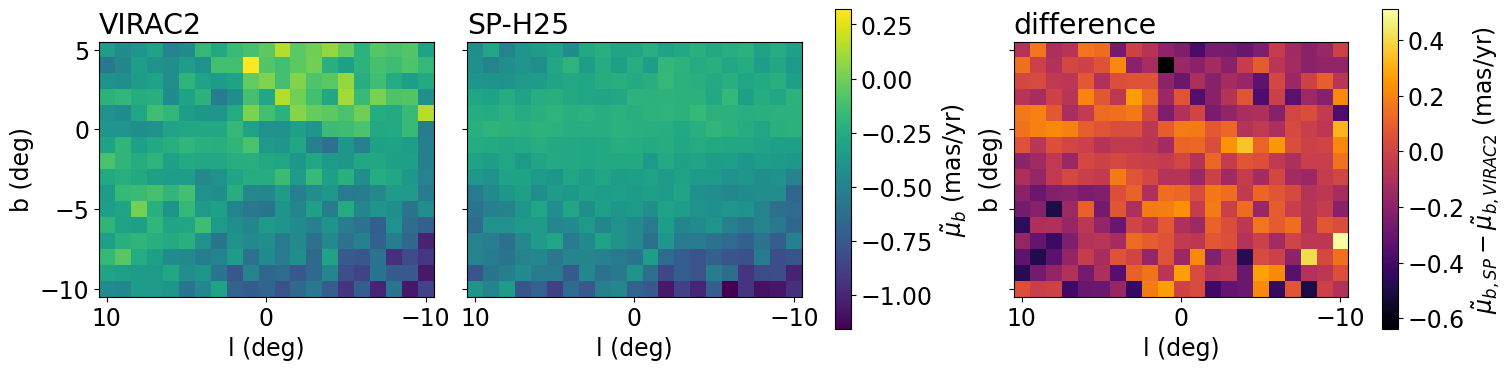

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharey=True)

vmin = np.min(vmub+smub)
vmax = np.max(vmub+smub)

vmubs = np.reshape(vmub,(21,16)).T
virac = axes[0].imshow(vmubs, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("VIRAC2", loc='left')
axes[0].set_xlabel("l (deg)")
axes[0].set_ylabel("b (deg)")
axes[0].invert_xaxis()

smubs = np.reshape(smub,(21,16)).T
synthpop = axes[1].imshow(smubs, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("SP-H25", loc='left')
axes[1].set_xlabel("l (deg)")
axes[1].invert_xaxis()
fig.colorbar(synthpop, ax=axes[1], orientation="vertical", label=r"$\tilde{\mu}_b$ (mas/yr)", shrink=0.65)


diff = axes[2].imshow(smubs-vmubs, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="inferno")#, vmin=vmin, vmax=vmax)
axes[2].set_title("difference", loc='left')
axes[2].set_xlabel("l (deg)")
axes[2].set_ylabel("b (deg)")
axes[2].invert_xaxis()

fig.colorbar(diff, ax=axes[2], orientation="vertical", 
             label=r"$\tilde{\mu}_{b,SP}-\tilde{\mu}_{b,VIRAC2}$ (mas/yr)", shrink=0.65)

plt.savefig("figures/virac_mub_maps.pdf")
plt.show()

In [32]:
def plot_hist(l,b,maglim=16):
    vcat = get_virac2(l,b)
    vcat = vcat[vcat['MedKsmag']<maglim]
    scat = get_spcat(l,b)
    scat = scat[scat['VISTA_Ks']<maglim]

    mulbins = np.linspace(-25,15,21)
    vhist,_ = np.histogram(vcat['pml'], bins=mulbins)
    plt.errorbar(mulbins[1:]-np.diff(mulbins)/2, vhist/np.sum(vhist), yerr=np.sqrt(vhist)/np.sum(vhist), 
                 marker='.', color='k', linestyle='none')
    shist,_ = np.histogram(scat['mul'], bins=mulbins)
    plt.stairs(shist/np.sum(shist), mulbins)

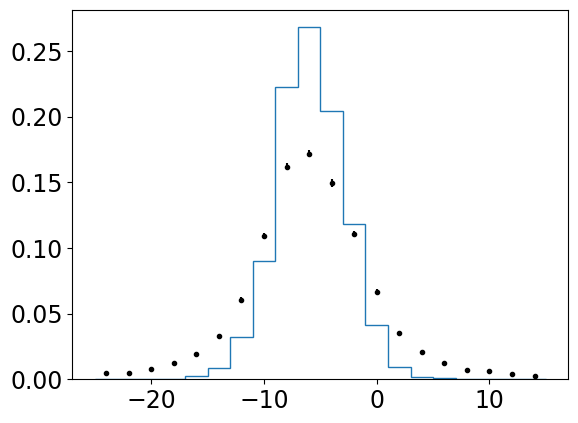

In [33]:
plot_hist(0,1)

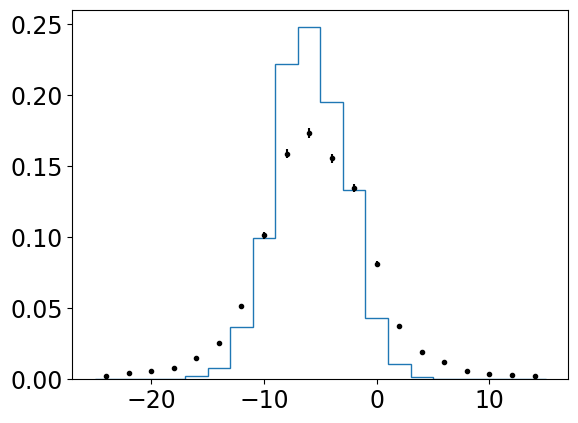

In [34]:
plot_hist(-1,-1)

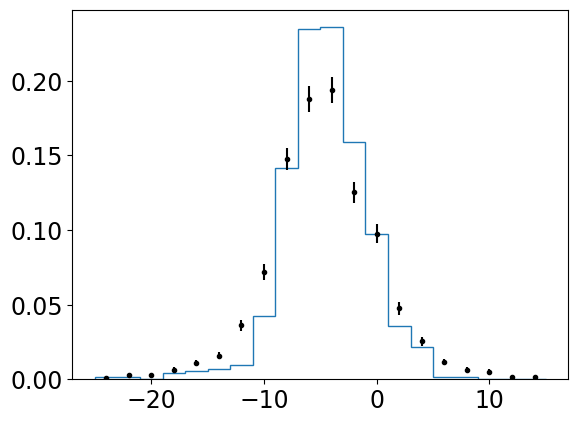

In [35]:
plot_hist(9,-8)

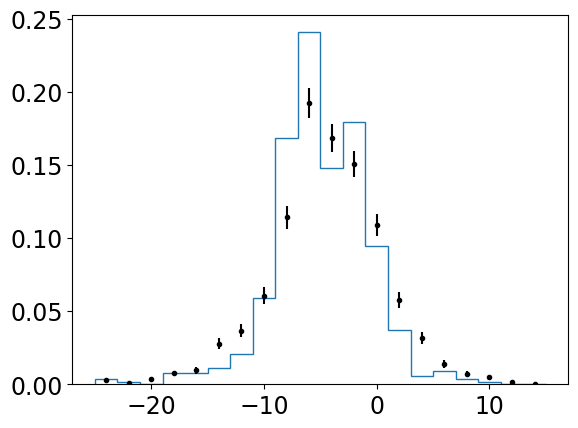

In [36]:
plot_hist(-9,-8)